In [1]:
import numpy as np
import torch
import random
import segmentation_models_pytorch as smp
import matplotlib.pyplot as plt

from joblib import Parallel, delayed
from segmentation_models_pytorch.losses import DiceLoss
from torch import nn
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from config import config
from tqdm.auto import tqdm
from utils import (
    build_metadata, split_metadata,
    print_split_summary, preprocess_img, sample_pixels,
    count_by_class, plot_class_distribution
)

/home/mohamed-ashraf/Desktop/projects/env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
print("DEVICE:", config.DEVICE)

DEVICE: cuda


In [3]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(config.RANDOM_STATE)

In [4]:
meta = build_metadata(config.DATA_DIR)
train_meta, val_meta, test_meta = split_metadata(meta)

print_split_summary('train', train_meta)
print_split_summary('val', val_meta)
print_split_summary('test', test_meta)

Scanning masks: 100%|██████████| 373/373 [00:00<00:00, 510.01it/s]

[train] images: 298
  Unknown  pixels=   10,265 images= 92
  Greenery pixels=12,651,254 images=280
  Sand     pixels=5,603,841 images=247
  Water    pixels=  495,736 images= 50
  Cement   pixels=  768,632 images=232
  strata: {'cement_only__w_0__c_101_1k': 85, 'base__w_0__c_0': 58, 'cement_only__w_0__c_1_100': 56, 'cement_only__w_0__c_1k_10k': 35, 'cement_only__w_0__c_gt_10k': 14, 'water_and_cement__w_1_100__c_101_1k': 8, 'water_and_cement__w_101_1k__c_101_1k': 6, 'water_only__w_gt_10k__c_0': 6, 'water_and_cement__w_1_100__c_1_100': 5, 'water_and_cement__w_101_1k__c_1k_10k': 4, 'water_and_cement__w_1k_10k__c_101_1k': 4, 'water_and_cement__w_1_100__c_1k_10k': 3, 'water_and_cement__w_gt_10k__c_1k_10k': 2, 'water_and_cement__w_1k_10k__c_1_100': 2, 'water_only__w_101_1k__c_0': 2, 'water_and_cement__w_101_1k__c_gt_10k': 2, 'water_and_cement': 2, 'water_and_cement__w_1k_10k__c_1k_10k': 2, 'water_and_cement__w_gt_10k__c_1_100': 2}
[val] images: 37
  Unknown  pixels=      645 images= 15
  Gree

In [5]:
class LandCoverSegDataset(Dataset):
    def __init__(self, X, y, transform=None):
        self.X = X
        self.y = y
        self.transform = transform

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        img = self.X[idx].astype(np.float32)
        mask = self.y[idx].astype(np.int64)

        if self.transform is not None:
            img, mask = self.transform(img, mask)

        img = np.ascontiguousarray(img)
        mask = np.ascontiguousarray(mask)
        return torch.from_numpy(img), torch.from_numpy(mask)

In [6]:
def process_pair(img_path, mask_path):
    img, mask, confidence, pixel_valid = preprocess_img(img_path, mask_path)

    valid = pixel_valid & (mask != 0) & (confidence * 100.0 >= config.MIN_CONFIDENCE)
    img = img.astype(np.float32)
    mask = mask.astype(np.uint8).copy()
    confidence = confidence.astype(np.float32)
    mask[~valid] = 0

    return img, mask, confidence


def build_dataset(split_df, n_jobs=-1):
    records = split_df[['img_path', 'mask_path']].to_dict('records')
    results = Parallel(n_jobs=n_jobs, backend='loky')(
        delayed(process_pair)(row['img_path'], row['mask_path'])
        for row in tqdm(records, desc='Building dataset')
    )

    X_parts = []
    y_parts = []
    weight_parts = []

    for X, y, pixel_weight in results:
        X_parts.append(X)
        y_parts.append(y)
        weight_parts.append(pixel_weight)

    X_all = np.stack(X_parts, axis=0)
    y_all = np.stack(y_parts, axis=0)
    weight_all = np.stack(weight_parts, axis=0)
    return X_all, y_all, weight_all

Building dataset: 100%|██████████| 38/38 [00:00<00:00, 30123.52it/s]


Train full: (298, 12, 256, 256) {'Greenery': 12655662, 'Sand': 5571348, 'Water': 436554, 'Cement': 769928}
Val full  : (37, 12, 256, 256) {'Greenery': 1673394, 'Sand': 541896, 'Water': 75697, 'Cement': 133789}
Test full : (38, 12, 256, 256) {'Greenery': 1779927, 'Sand': 635782, 'Water': 2843, 'Cement': 71805}
Greenery available=12,655,662 sampled=12,655,662
Sand     available=5,571,348 sampled=5,571,348
Water    available=  436,554 sampled=  436,554
Cement   available=  769,928 sampled=  769,928
Train sampled: (298, 12, 256, 256) {'Greenery': 12655662, 'Sand': 5571348, 'Water': 436554, 'Cement': 769928}
Val full     : (37, 12, 256, 256) {'Greenery': 1673394, 'Sand': 541896, 'Water': 75697, 'Cement': 133789}
Test full    : (38, 12, 256, 256) {'Greenery': 1779927, 'Sand': 635782, 'Water': 2843, 'Cement': 71805}
Ignored train pixels: 96236
Train confidence weight range: 0.33000001311302185 1.0


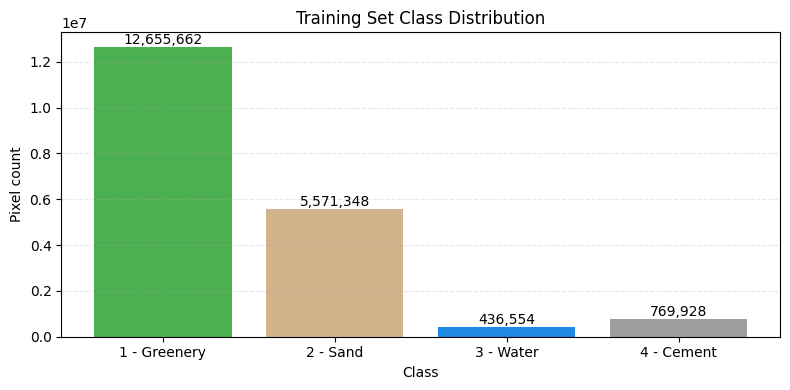

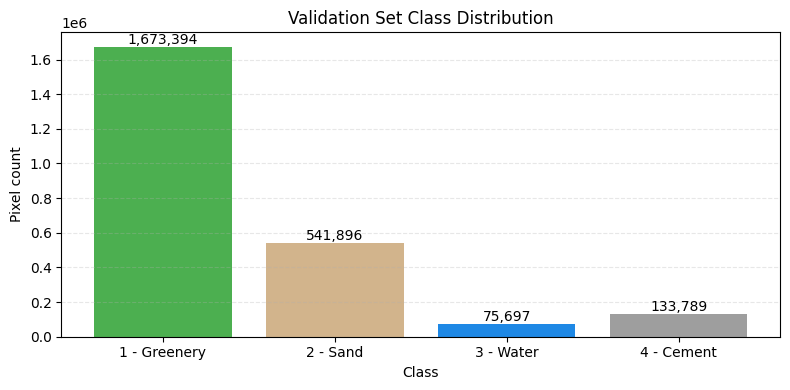

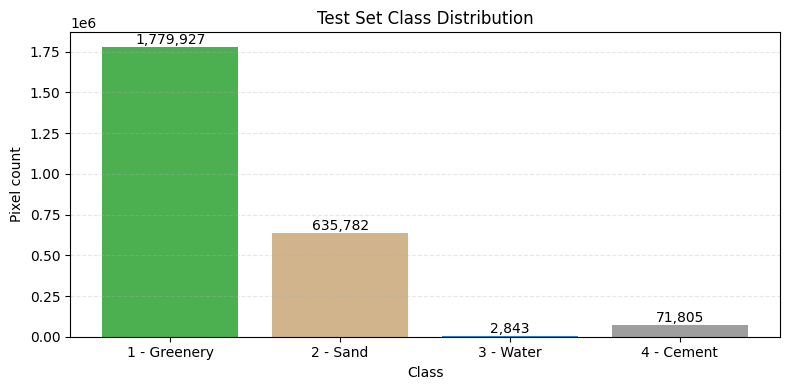

In [ ]:
X_train, y_train, conf_train = build_dataset(train_meta)
X_val, y_val, conf_val = build_dataset(val_meta)
X_test, y_test, conf_test = build_dataset(test_meta)

print('Train full:', X_train.shape, count_by_class(y_train[y_train != 0]))
print('Val full  :', X_val.shape, count_by_class(y_val[y_val != 0]))
print('Test full :', X_test.shape, count_by_class(y_test[y_test != 0]))

train_valid = y_train != 0
val_valid = y_val != 0
test_valid = y_test != 0

print('Ignored train pixels:', int((~train_valid).sum()))
print('Train confidence weight range:', float(conf_train[train_valid].min()), float(conf_train[train_valid].max()))
plot_class_distribution(y_train[train_valid], 'Training Set Class Distribution')
plot_class_distribution(y_val[val_valid], 'Validation Set Class Distribution')
plot_class_distribution(y_test[test_valid], 'Test Set Class Distribution')

In [8]:
class SatelliteTrainTransform:
    def __init__(
        self,
        hflip_p=0.5,
        vflip_p=0.5,
        rotate_p=0.75,
        transpose_p=0.3,
        noise_p=0.2,
        intensity_p=0.2,
        noise_std=0.01,
        gain_range=(0.95, 1.05),
        bias_range=(-0.03, 0.03),
    ):
        self.hflip_p = hflip_p
        self.vflip_p = vflip_p
        self.rotate_p = rotate_p
        self.transpose_p = transpose_p
        self.noise_p = noise_p
        self.intensity_p = intensity_p
        self.noise_std = noise_std
        self.gain_range = gain_range
        self.bias_range = bias_range

    def __call__(self, img, mask):
        if random.random() < self.hflip_p:
            img = np.flip(img, axis=2)
            mask = np.flip(mask, axis=1)

        if random.random() < self.vflip_p:
            img = np.flip(img, axis=1)
            mask = np.flip(mask, axis=0)

        if random.random() < self.rotate_p:
            k = random.randint(0, 3)
            if k:
                img = np.rot90(img, k=k, axes=(1, 2))
                mask = np.rot90(mask, k=k, axes=(0, 1))

        if random.random() < self.transpose_p:
            img = np.transpose(img, (0, 2, 1))
            mask = np.transpose(mask, (1, 0))

        if random.random() < self.intensity_p:
            gain = np.float32(np.random.uniform(*self.gain_range))
            bias = np.float32(np.random.uniform(*self.bias_range))
            img = np.clip(img * gain + bias, 0.0, 1.0)

        if random.random() < self.noise_p:
            noise = np.random.normal(0.0, self.noise_std, size=img.shape).astype(np.float32)
            img = np.clip(img + noise, 0.0, 1.0)

        return img.astype(np.float32), mask.astype(np.int64)


train_transform = SatelliteTrainTransform()

train_ds = LandCoverSegDataset(X_train, y_train, transform=train_transform)
val_ds   = LandCoverSegDataset(X_val, y_val)
test_ds  = LandCoverSegDataset(X_test, y_test)


train_loader = DataLoader(
    train_ds,
    batch_size=config.BATCH_SIZE,
    shuffle=True,
    num_workers=config.NUM_WORKERS,
    pin_memory=True,
)

val_loader = DataLoader(
    val_ds,
    batch_size=config.BATCH_SIZE,
    shuffle=False,
    num_workers=config.NUM_WORKERS,
    pin_memory=True,
)

test_loader = DataLoader(
    test_ds,
    batch_size=config.BATCH_SIZE,
    shuffle=False,
    num_workers=config.NUM_WORKERS,
    pin_memory=True,
)

print('Dataset sizes:', len(train_ds), len(val_ds), len(test_ds))
print('Train images with cement:', int(train_meta['has_cement'].sum()))
print('Train images with water :', int(train_meta['has_water'].sum()))

Dataset sizes: 298 37 38
Train images with cement: 232
Train images with water : 50


In [9]:
class_weights = torch.tensor([0.0, 1.0, 1.0, 2.0, 2.5], device=config.DEVICE)

ce_loss = nn.CrossEntropyLoss(
    weight=class_weights,
    ignore_index=config.IGNORE_INDEX
)

dice_loss = DiceLoss(
    mode="multiclass",
    ignore_index=config.IGNORE_INDEX
)

def criterion(logits, targets):
    return 0.7 * ce_loss(logits, targets) + 0.3 * dice_loss(logits, targets)

cr = criterion

In [ ]:
class UNet(nn.Module):
    def __init__(self, encoder_name="resnet34", num_classes=5):
        super().__init__()

        self.stem = nn.Sequential(
            nn.Conv2d(12, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            nn.Conv2d(32, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            nn.Conv2d(32, 12, kernel_size=1, bias=False),
            nn.BatchNorm2d(12),
            nn.ReLU(inplace=True),
        )

        self.unet = smp.Unet(
            encoder_name=encoder_name,
            encoder_weights=None,
            in_channels=12,
            classes=num_classes,
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.unet(x)
        return x


model = UNet(
    encoder_name="resnet34",
    num_classes=5
).to(config.DEVICE)

optimizer = torch.optim.AdamW(model.parameters(), lr=config.LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=5,
)

print(sum(p.numel() for p in model.parameters()) / 1e6, "M parameters")

24.478381 M parameters


In [11]:
images, masks = next(iter(train_loader))
images = images.to(config.DEVICE)
masks = masks.to(config.DEVICE)

with torch.no_grad():
    out = model(images)

print("Input shape :", images.shape)
print("Mask shape  :", masks.shape)
print("Output shape:", out.shape)

Input shape : torch.Size([8, 12, 256, 256])
Mask shape  : torch.Size([8, 256, 256])
Output shape: torch.Size([8, 5, 256, 256])


In [12]:
def compute_dataset_iou(conf_mat, ignore_index=0):
    ious = []

    for cls in range(conf_mat.shape[0]):
        if cls == ignore_index:
            continue

        tp = conf_mat[cls, cls]
        fp = conf_mat[:, cls].sum() - tp
        fn = conf_mat[cls, :].sum() - tp
        union = tp + fp + fn

        if union > 0:
            ious.append(tp / union)

    return float(np.mean(ious)) if ious else 0.0


def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0

    for images, masks in tqdm(loader, desc='Training'):
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad(set_to_none=True)
        logits = model(images)
        loss = criterion(logits, masks)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


@torch.no_grad()
def validate(model, loader, criterion, device, num_classes=5, ignore_index=0):
    model.eval()
    total_loss = 0.0
    conf_mat = np.zeros((num_classes, num_classes), dtype=np.int64)

    for images, masks in loader:
        images = images.to(device)
        masks = masks.to(device)

        logits = model(images)
        loss = criterion(logits, masks)

        preds = torch.argmax(logits, dim=1)
        valid = masks != ignore_index
        preds_valid = preds[valid]
        masks_valid = masks[valid]

        if masks_valid.numel() > 0:
            indices = (masks_valid.view(-1) * num_classes + preds_valid.view(-1)).to(torch.int64)
            batch_conf = torch.bincount(indices, minlength=num_classes * num_classes)
            conf_mat += batch_conf.reshape(num_classes, num_classes).cpu().numpy()

        total_loss += loss.item()

    mean_loss = total_loss / len(loader)
    mean_iou = compute_dataset_iou(conf_mat, ignore_index=ignore_index)
    return mean_loss, mean_iou, conf_mat

In [13]:
num_epochs = 100
early_stopping_patience = 50
best_val_iou = -1.0
epochs_without_improvement = 0

for epoch in range(num_epochs):
    train_loss = train_one_epoch(model, train_loader, optimizer, cr, config.DEVICE)
    val_loss, val_iou, val_conf_mat = validate(
        model,
        val_loader,
        cr,
        config.DEVICE,
        num_classes=config.NUM_CLASSES,
        ignore_index=config.IGNORE_INDEX,
    )
    scheduler.step(val_iou)
    current_lr = optimizer.param_groups[0]['lr']

    print(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_loss:.4f} | "
        f"val_mIoU={val_iou:.4f} | "
        f"lr={current_lr:.2e}"
    )

    if val_iou > best_val_iou + 1e-4:
        best_val_iou = val_iou
        epochs_without_improvement = 0
        torch.save(model.state_dict(), "best_unet.pth")
        print("Saved best model")
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= early_stopping_patience:
            print("Early stopping triggered")
            break

Training: 100%|██████████| 38/38 [00:06<00:00,  6.20it/s]


Epoch 1/100 | train_loss=1.2580 | val_loss=0.9795 | val_mIoU=0.2142 | lr=3.00e-04
Saved best model


Training: 100%|██████████| 38/38 [00:05<00:00,  6.83it/s]


Epoch 2/100 | train_loss=0.8425 | val_loss=0.6402 | val_mIoU=0.5672 | lr=3.00e-04
Saved best model


Training: 100%|██████████| 38/38 [00:05<00:00,  6.97it/s]


...

Epoch 98/100 | train_loss=0.3595 | val_loss=0.3319 | val_mIoU=0.7704 | lr=2.93e-07


Training: 100%|██████████| 38/38 [00:05<00:00,  6.79it/s]


Epoch 99/100 | train_loss=0.3726 | val_loss=0.3337 | val_mIoU=0.7677 | lr=2.93e-07


Training: 100%|██████████| 38/38 [00:05<00:00,  6.79it/s]


Epoch 100/100 | train_loss=0.3416 | val_loss=0.3385 | val_mIoU=0.7703 | lr=2.93e-07


In [14]:
checkpoint = torch.load("best_unet.pth", map_location=config.DEVICE)
model = UNet(
    encoder_name="resnet34",
    num_classes=5
).to(config.DEVICE)
model.load_state_dict(checkpoint)
model.eval()

UNet(
  (stem): Sequential(
    (0): Conv2d(12, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): Conv2d(32, 12, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (7): BatchNorm2d(12, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
  )
  (unet): Unet(
    (encoder): ResNetEncoder(
      (conv1): Conv2d(12, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1):

In [15]:
val_loss, val_iou, val_conf_mat = validate(
    model,
    val_loader,
    criterion,
    config.DEVICE,
    num_classes=config.NUM_CLASSES,
    ignore_index=config.IGNORE_INDEX,
)
print(f"Validation | loss={val_loss:.4f} | mIoU={val_iou:.4f}")

for cls in range(config.NUM_CLASSES):
    if cls == config.IGNORE_INDEX:
        continue

    tp = val_conf_mat[cls, cls]
    fp = val_conf_mat[:, cls].sum() - tp
    fn = val_conf_mat[cls, :].sum() - tp
    union = tp + fp + fn
    class_iou = tp / union if union > 0 else float('nan')
    print(f"  {config.CLASS_NAMES[cls]} IoU: {class_iou:.4f}")

Validation | loss=0.3373 | mIoU=0.7719
  Greenery IoU: 0.8571
  Sand IoU: 0.6159
  Water IoU: 0.9270
  Cement IoU: 0.6875


In [16]:
@torch.no_grad()
def show_prediction(model, split_df, idx=0):
    if isinstance(model, dict):
        loaded_model = UNet(
            encoder_name="resnet34",
            num_classes=5
        ).to(config.DEVICE)
        loaded_model.load_state_dict(model)
        model = loaded_model

    model.eval()

    row = split_df.iloc[idx]
    image_np, mask_np, _, _ = preprocess_img(row["img_path"], row["mask_path"])

    x = torch.from_numpy(image_np.astype(np.float32)).unsqueeze(0).to(config.DEVICE)

    logits = model(x)
    pred = torch.argmax(logits, dim=1).squeeze(0).cpu().numpy()

    mask_values, mask_counts = np.unique(mask_np, return_counts=True)
    pred_values, pred_counts = np.unique(pred, return_counts=True)

    print("Mask: ", dict(zip(mask_values, mask_counts)))
    print("Prediction: ", dict(zip(pred_values, pred_counts)))

    rgb = np.transpose(image_np[[3, 2, 1]], (1, 2, 0))
    rgb = np.clip(rgb * 3.0, 0, 1)

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(rgb)
    plt.title("RGB")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(mask_np, cmap="tab10", vmin=0, vmax=4)
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(pred, cmap="tab10", vmin=0, vmax=4)
    plt.title("Prediction")
    plt.axis("off")

    plt.show()

Mask:  {np.uint8(1): np.int64(65086), np.uint8(2): np.int64(80), np.uint8(4): np.int64(370)}
Prediction:  {np.int64(1): np.int64(65498), np.int64(4): np.int64(38)}


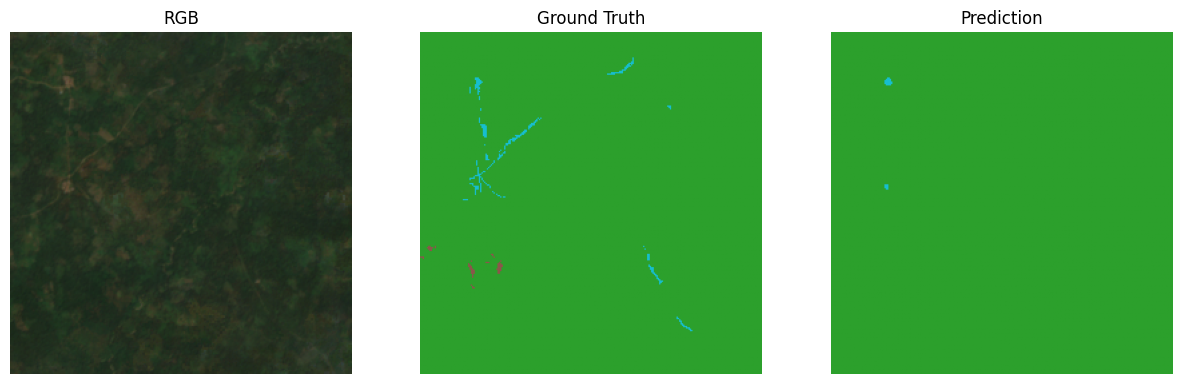

In [29]:
show_prediction(model, train_meta, idx=62)